✅ Accuracy: 0.8100558659217877

🧾 Matriz de Confusión:
 [[90 15]
 [19 55]]

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



C:\Users\MAYRA ROCIO\AppData\Local\Temp\ipykernel_34220\449872226.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\MAYRA ROCIO\AppData\Local\Temp\ipykernel_34220\449872226.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

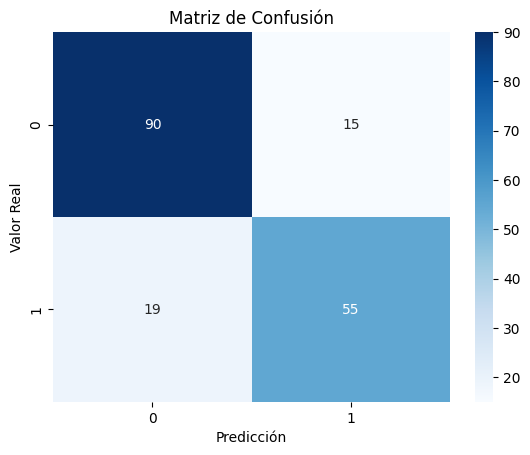

In [1]:
# titanic_modelo_ml.py

# 🔧 Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📥 Cargar datos
df = pd.read_csv("train.csv")

# 🧹 Limpieza y preprocesamiento
df = df.drop(["Cabin", "Ticket", "Name", "PassengerId"], axis=1)
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# ✂️ Separar variables predictoras y objetivo
X = df.drop("Survived", axis=1)
y = df["Survived"]

# 📊 División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🤖 Entrenamiento del modelo
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# 📈 Evaluación
y_pred = modelo.predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n🧾 Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\n📋 Reporte de Clasificación:\n", classification_report(y_test, y_pred))

# (Opcional) Visualización de la matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()
